# Implementing a MLP for binary classification (with numpy only). 

For this we will use the iris data set composed of a 150 instances of labled data with features sepal length, sepal width, petal length, and petal width.

## 1 Importing the Data 
##### The Iris Dataset
This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length.
This data is stored in a datatype bunch that includes multiple numpy arrays.
the data Nd array has a shape of 150x4
```python
{'data': array([[5.1, 3.5, 1.4, 0.2],
                [4.9, 3., 1.4, 0.2],
                [4.7, 3.2, 1.3, 0.2],
                [4.6, 3.1, 1.5, 0.2],...
'target': array([0, 0, 0, ... 1, 1, 1, ... 2, 2, 2, ...
'target_names': array(['setosa', 'versicolor', 'virginica'], dtype='<U10'),
...}
```
the 4 colomns of the array representing the 4 features in the dataset:
1. Sepal Length (0)
2. Sepal Width (1)
3. Petal Length **(2)** 
4. Petal Width. **(3)**

there are 3 types of iris so the targets 0,1,2 respectively are the labels, their order coresponds the same as the target names. 


**Lets import our dataset and reshape it into something more apropriate for binary classifcation**



In [22]:
import numpy as np
from sklearn import datasets

# load iris dataset
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # slices ndarry to contain all rows and colomns 2,3 (petal length, petal width)
y = (iris["target"] == 2).astype(int)  # Gets the target array for when Iris-Virginica, uses as type int to convert boolian to 1 and 0.
print(X)
print(y) # Just 150 values in a flat array
print(y.shape)
y = y.reshape([150,1]) # 2D array for compatibity with other functions. 

[[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [1.7 0.4]
 [1.4 0.3]
 [1.5 0.2]
 [1.4 0.2]
 [1.5 0.1]
 [1.5 0.2]
 [1.6 0.2]
 [1.4 0.1]
 [1.1 0.1]
 [1.2 0.2]
 [1.5 0.4]
 [1.3 0.4]
 [1.4 0.3]
 [1.7 0.3]
 [1.5 0.3]
 [1.7 0.2]
 [1.5 0.4]
 [1.  0.2]
 [1.7 0.5]
 [1.9 0.2]
 [1.6 0.2]
 [1.6 0.4]
 [1.5 0.2]
 [1.4 0.2]
 [1.6 0.2]
 [1.6 0.2]
 [1.5 0.4]
 [1.5 0.1]
 [1.4 0.2]
 [1.5 0.2]
 [1.2 0.2]
 [1.3 0.2]
 [1.4 0.1]
 [1.3 0.2]
 [1.5 0.2]
 [1.3 0.3]
 [1.3 0.3]
 [1.3 0.2]
 [1.6 0.6]
 [1.9 0.4]
 [1.4 0.3]
 [1.6 0.2]
 [1.4 0.2]
 [1.5 0.2]
 [1.4 0.2]
 [4.7 1.4]
 [4.5 1.5]
 [4.9 1.5]
 [4.  1.3]
 [4.6 1.5]
 [4.5 1.3]
 [4.7 1.6]
 [3.3 1. ]
 [4.6 1.3]
 [3.9 1.4]
 [3.5 1. ]
 [4.2 1.5]
 [4.  1. ]
 [4.7 1.4]
 [3.6 1.3]
 [4.4 1.4]
 [4.5 1.5]
 [4.1 1. ]
 [4.5 1.5]
 [3.9 1.1]
 [4.8 1.8]
 [4.  1.3]
 [4.9 1.5]
 [4.7 1.2]
 [4.3 1.3]
 [4.4 1.4]
 [4.8 1.4]
 [5.  1.7]
 [4.5 1.5]
 [3.5 1. ]
 [3.8 1.1]
 [3.7 1. ]
 [3.9 1.2]
 [5.1 1.6]
 [4.5 1.5]
 [4.5 1.6]
 [4.7 1.5]
 [4.4 1.3]
 [4.1 1.3]
 [4.  1.3]
 [4.4 1.2]

## 2 Defining the Activation Function
and its derirative for later use

In [23]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

Sigmoid(z) 
$$ y = \frac{1}{1+e^{-z}}$$
Sigmoid(z) derriative
$$sigmoid*(1-sigmoid)$$

## 3 Defineing the MLP Class 
- `__init__` method that initializes the weights and biases of the MLP
- `fit` method that trains the MLP on the training data
- `predict` method that uses the trained MLP to make predictions on new data
<br>  
<br>
 - **input_size** is the number of input features
 - **hidden_size** is the number of neurons in the hidden layer
 - **output_size** is the number of output classes
 - **learning_rate** is the learning rate used in the training process.

 [[Deep dive Into initialisation]]
 [[Deep dive into training]]
 [[Deep dive into prediction]]


Example class 
```python
mlp = MLP(input_size=2, hidden_size=4, output_size=1)
```
 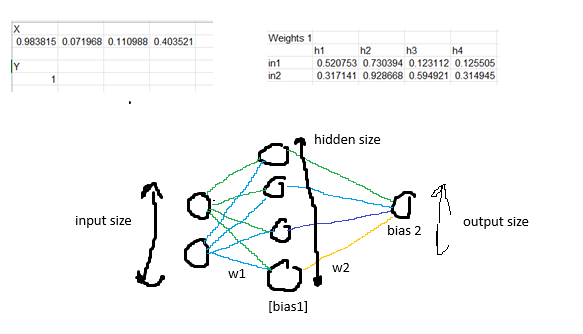 <br>
  X and Y in the image above would be a specific index of the data and label arrays 
  
 Note how this coresponds to the typical notation for neural neworks $$Position_{h,i}$$ of the array coresponds to $$W_{jk}$$ where k is the neron you came from in feed foward (or too in back prop) and j is the neron your going towards in feed foward. $W_{jk}$ where k is the neron you came from in feed foward (or too in back prop) and j is the neron your going towards in feed foward.

In [24]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        
        # initialize weights randomly
        self.weights1 = np.random.randn(self.input_size, self.hidden_size) # Arguments are depth and lengh of the array so if input = 2 and hidden =4 it would be 2 rows of 4 lengh 
        self.weights2 = np.random.randn(self.hidden_size, self.output_size) # output is size 1 as this is binary classificaiton,  in this case hidden number of rows of lengh 1. 
        print("The Inital Shape of the MLP is:  \n  Weights1: \n" )
        print(self.weights1) # W1(2,4)
        print("\n Each row representing the connections from each nuron in the input layer to every other neron in the hidden layer" )
        print("\n Weights2: \n" )
        print(self.weights2)  # W2 (4,1)
        print("\n Each row representing the weights connecting to the final output neron. (or each neron in the next layer if more layers as before) ")
            
        # initialize biases to 0
        self.bias1 = np.zeros((1, self.hidden_size))
        self.bias2 = np.zeros((1, self.output_size))
    
    ### Training the Neural network ~~~~~~~~~~~~~~
    def fit(self, X, y, epochs=1000):
        for epoch in range(epochs):
            # feedforward
            layer1 = X.dot(self.weights1) + self.bias1 # X(150,2) w1(2,4) => Layer1(150,4) each row being the coresponding activations of layer 1 for a given input X. 
            activation1 = sigmoid(layer1)
            layer2 = activation1.dot(self.weights2) + self.bias2 # Activation(150,4) Weight2(4,1) => Layer2(150,1)
            activation2 = sigmoid(layer2) # (activation(150,1))
            
            # backpropagation
            error = activation2 - y
            d_weights2 = activation1.T.dot(error * sigmoid_derivative(layer2)) # a1_T(4,150) , error+sig'(150,1 )
            d_bias2 = np.sum(error * sigmoid_derivative(layer2), axis=0, keepdims=True)
            error_hidden = error.dot(self.weights2.T) * sigmoid_derivative(layer1)
            d_weights1 = X.T.dot(error_hidden)
            d_bias1 = np.sum(error_hidden, axis=0, keepdims=True)
            
            # update weights and biases
            self.weights2 -= self.learning_rate * d_weights2
            self.bias2 -= self.learning_rate * d_bias2
            self.weights1 -= self.learning_rate * d_weights1
            self.bias1 -= self.learning_rate * d_bias1
    

    def predict(self, X):
        layer1 = X.dot(self.weights1) + self.bias1
        activation1 = sigmoid(layer1)
        layer2 = activation1.dot(self.weights2) + self.bias2
        activation2 = sigmoid(layer2)
        return (activation2 > 0.5).astype(int)


#### Setup and feed foward. 
$$Layer_1 = z_1 = (X\cdot weights) + bias $$
$$Layer_2 = z_2 = (X\cdot weights) + bias $$
$$activation_1 = \sigma(z_1)$$
$$activation_2 = \sigma(z_2)$$
#### Dot product for matrix multiplication
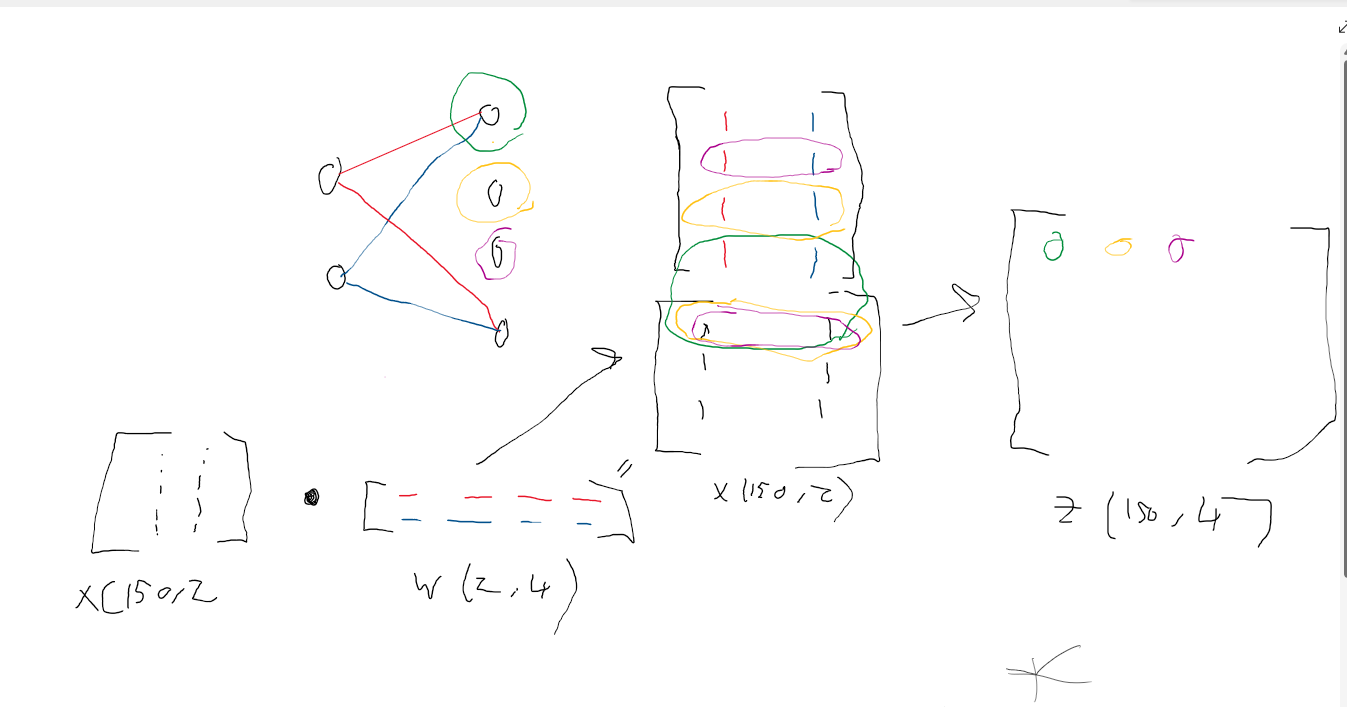 <br>
- Layer 1 and 2 here represent the Hidden layer and the output layer respectively in this highly non generalised example. 
- Earlier on we set the input array X to corespond to the features petal lengh and petal width (colomns 2,3 from iris data). 
- Data is fed foward starting with these X values in layer 1's activation function and then using the activation of that previous layer 1 in the actviation function for layer 2. 

#### Back propergation. 
This code Assumes the Mean sqauared error as a cost function, Ie
$$ C = \frac{1}{2}(a^2 - y^2)^2$$
If we wish to find the sensitivy of cost function to the weights and biases we find this using the chain rule
$$ \frac{\delta C}{\delta W} = \frac{\delta C}{\delta a}\frac{\delta a}{\delta z}\frac{\delta z}{\delta W}$$
$$\frac{\delta C}{\delta b} = \frac{\delta C}{\delta a}\frac{\delta a}{\delta z}\frac{\delta z}{\delta b}$$
the error: 
```python 
error = activation - y
```
is the cost function C diffrentiated with respect to the activation 
$$ \frac{\delta C}{\delta a} =  a-y = error $$

Hence the above equations become 
$$ \frac{\delta C}{\delta W} = \frac{\delta C}{\delta a}\frac{\delta a}{\delta z}\frac{\delta z}{\delta W} =  (error)(\sigma^{\prime}(z_2))(a^{L-1})  $$
$$   = error * a^{L-1} \sigma^{\prime}(z_2)$$
$$ \frac{\delta C}{\delta b} = \frac{\delta C}{\delta a}\frac{\delta a}{\delta z}\frac{\delta z}{\delta b}  (error)(\sigma^{\prime}(z_2))(1) =  error * \sigma^{\prime}(z_2) $$
$$ =  error * \sigma^{\prime}(z_2)$$ 

Lets Consider how this is implemented in code: 
```python
d_weights2 = activation1.T.dot(error * sigmoid_derivative(layer2))
```
d_weight2 is represented by this equation. 

$$ \delta W^{L2} = a^{L1^T} \cdot ( error  * \sigma^{\prime}(z_2))  $$  

The activiations for Layer 1 are going to have the same shape as the z functions ie (150,4)
```python
a^L1 ('where each colomn can be thought of as a neron in the hidden layer and each row for a given X value' )
[[ 0.27026169 -0.52565191 -0.81854089  0.15292456]
 [-1.35141601 -0.80568831 -1.26671321  0.85843448]
 [-1.35141601 -0.80568831 -1.26671321  0.85843448]
 [-1.35141601 -0.80568831 -1.26671321  0.85843448]
 .
 .
 .
 ]

Transposed  this becomes (4,150)
[[0.27026169  -1.35141601 -1.35141601 -0.80568831 -1.26671321  0.85843448 ...]
 [-0.52565191 -0.80568831 -1.35141601 -0.80568831 -1.26671321  0.85843448 ...]
 [-0.81854089 -1.26671321 -1.35141601 -0.80568831 -1.26671321  0.85843448 ...]
 [0.15292456  0.85843448  -1.35141601 -0.80568831 -1.26671321  0.85843448 ...]
]
```
as $z_2$ has shape (150,1) so to does its derirative. error also has this same shape for 150 training examples. 
thus the dot product combines matracies of (4,150) and (150,1) shape. giving a matrix of shape (4,1) the wieghts of each neron in the hidden layer going to the output neron. 

```python

```

d_weights2 = activation1.T.dot(error * sigmoid_derivative(layer2))
            d_bias2 = np.sum(error * sigmoid_derivative(layer2), axis=0, keepdims=True)
            error_hidden = error.dot(self.weights2.T) * sigmoid_derivative(layer1)
            d_weights1 = X.T.dot(error_hidden)
            d_bias1 = np.sum(error_hidden, axis=0, keepdims=True)




array([[1, 2],
       [3, 4]])
a.T
array([[1, 3],
       [2, 4]])


#### Feed foward
this implementation is extremely breif and non generalised. 




In [25]:
# create an instance of the MLP class
mlp = MLP(input_size=2, hidden_size=4, output_size=1)

# train the MLP on the training data
mlp.fit(X, y)

# make predictions on the test data
y_pred = mlp.predict(X)

# evaluate the accuracy of the MLP
accuracy = np.mean(y_pred == y)
print(f"Accuracy: {accuracy:.2f}")

The Inital Shape of the MLP is:  
  Weights1: 

[[ 1.37198583  1.49876396  0.9136535   0.06041145]
 [ 0.01126161  1.11098514  1.05126846 -1.51494598]]

 Each row representing the connections from each nuron in the input layer to every other neron in the hidden layer

 Weights2: 

[[0.20519397]
 [0.54427465]
 [1.17875629]
 [0.53983241]]

 Each row representing the weights connecting to the final output neron. (or each neron in the next layer if more layers as before) 
Accuracy: 0.97


# Refrences 
- https://abtinmy.github.io/CS-SBU-NeuralNetwork/lectures/introduction/MLP-Scratch-Iris  Github repo for the associated course

https://github.com/Abtinmy/CS-SBU-NeuralNetwork Overivew of the project. 

http://neuralnetworksanddeeplearning.com/  
https://www.3blue1brown.com/lessons/backpropagation-calculus
For a deeper understanding of the equations and dirvations


https://www.youtube.com/watch?v=LyGKycYT2v0 understanding the use of the dot product for elementwise multiplication and summation at a deeper level than just pure computation 
https://builtin.com/data-science/dot-product-matrix#:~:text=as%20matrix%20multiplication).-,A%20dot%20product%20is%20the%20sum%20of%20the%20products%20of,to%20form%20a%20new%20matrix.

https://www.youtube.com/watch?v=woa34ugDSwY computations with the dot product. 

In [26]:
import numpy as np
from sklearn import datasets

# load iris dataset
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # slices ndarry to contain all rows and colomns 2,3 (petal length, petal width)
y = (iris["target"] == 2).astype(int)  # Gets the target array for when Iris-Virginica, uses as type int to convert boolian to 1 and 0.
print(X[5,:])
print(X.shape)
print(y) # Just 150 values in a flat array
y = y.reshape([150,1]) # 2D array for compatibity with other functions. 

print("Weights 1 ")
weights1 = np.random.randn(2, 4)
print (weights1.shape)
print(weights1)
print("\n Layer 1")
layer1 = X.dot(weights1) 
print(layer1)
print(layer1.shape)
print (1.7*-0.12382783 - 0.4*0.97740604 )

[1.7 0.4]
(150, 2)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]
Weights 1 
(2, 4)
[[-0.93179215  0.92474294 -0.47534804  0.19134067]
 [-0.85692748 -1.11688727  0.34320262 -0.51814681]]

 Layer 1
[[-1.47589450e+00  1.07126266e+00 -5.96846730e-01  1.64247572e-01]
 [-1.47589450e+00  1.07126266e+00 -5.96846730e-01  1.64247572e-01]
 [-1.38271529e+00  9.78788369e-01 -5.49311926e-01  1.45113505e-01]
 [-1.56907372e+00  1.16373696e+00 -6.44381533e-01  1.83381639e-01]
 [-1.47589450e+00  1.07126266e+00 -5.96846730e-01  1.64247572e-01]
 [-1.92681764e+00  1.12530809e+00 -6.70810617e-01  1.18020410e-01]
 [-1.56158725e+00  9.59573936e-01 -5.62526468e-01  1.12432891e-01]
 [-1.56907372e+00  1.16373696e+00 -6.44381533e-01  1.83381639e-01]
 [-1.475